# Adjoint Optimization of a Polygon-Shaped Patch Antenna

In the previous notebooks, we optimized rectangular patch antennas by tuning widths, heights, and positions of box-shaped elements. While effective, rectangular patches limit the design space to axis-aligned geometries. In this notebook, we take a different approach by parameterizing the antenna patch as a smooth polygon using Tidy3D's `PolySlab` geometry. Instead of optimizing box dimensions, we optimize the radial extent of the patch at a set of control points distributed around its perimeter. A spline interpolation then produces a smooth, closed polygon from these control radii.

This parameterization naturally captures a much richer set of shapes — including asymmetric, multi-lobed, and organically curved patches — that would be difficult or impossible to represent with rectangular elements. The antenna is excited through a coaxial feed from below the ground plane, which is a common configuration in practice. As in the previous notebooks, we use the adjoint method to efficiently compute gradients with respect to all shape parameters simultaneously.

<div style="display: flex; gap: 10px; justify-content: center;">
    <img src="img/rf_autograd_3_patch_antenna_thumbnail.png" style="height:500px; object-fit: contain;"/>
</div>

In [37]:
import os
import pickle

import autograd.numpy as anp
import matplotlib.patches as mpl_patches
import matplotlib.pyplot as plt
import numpy as np
import optax
import tidy3d as td
import tidy3d.plugins.smatrix as smatrix
from autograd import value_and_grad
from rich.console import Console
from rich.text import Text
from tidy3d.plugins.autograd.primitives import interpolate_spline
from tidy3d.web import run

# Setup console and printing parameters for rich printing during optimization loops
console = Console()
print_decimal_places = 2  # how many decimal places to use in printing
print_iteration_frequency = 5  # how often to print optimization progress

## Configuration and Parameters

We set up the parameters for the optimization, including the target frequency, substrate geometry, and coaxial feed dimensions. The antenna uses a coaxial feed that passes through the ground plane from below, connecting to a small disc on the top surface of the substrate. The coaxial line dimensions are chosen so that the characteristic impedance matches the 50-ohm port impedance, using the standard formula $Z_0 = \frac{60}{\sqrt{\epsilon_r}} \ln\left(\frac{D_{outer}}{D_{inner}}\right)$ where the gap between the inner and outer conductors is air-filled ($\epsilon_r = 1$). As before, we use a scaling factor to convert Tidy3D's default unit of micrometers to millimeters (mm).

In [38]:
# length scales and geometric parameters for optimization
mm = 1e3  # mm scaling

# target wavelength and frequency for the antenna design
center_wavelength_target = 30 * mm
freq_target = td.C_0 / center_wavelength_target

# substrate geometric parameters
sub_width = 1.25 * center_wavelength_target
sub_height = sub_width

sub_x = [-0.5 * sub_width, 0.5 * sub_width]
sub_y = [-0.5 * sub_height, 0.5 * sub_height]
sub_z = 2.0 * mm  # total thickness of ground plane region
sub_thickness = 0.5 * mm  # thickness of dielectric between ground plane top and patch

# coaxial feed parameters — dimensions chosen for ~50 ohm air-filled coaxial impedance
coax_radius = 1.5 * mm / 4  # outer conductor radius
rfeed = 0.65 * mm / 4  # inner conductor (feed pin) radius
port_diameter = 2 * coax_radius
feed_disc_radius = 0.425 * mm  # radius of the feed disc connecting pin to patch
feed_center_x = 3.25 * mm  # x-offset of the coaxial feed from the center

# center and size for placing directivity and far field monitors
directivity_center_x = np.mean(sub_x)
directivity_center_y = np.mean(sub_y)
directivity_size_x = 5 * mm + sub_x[1] - sub_x[0]
directivity_size_y = 5 * mm + sub_y[1] - sub_y[0]

# frequency range (Hz) for simulating
freq_start = 7e9
freq_stop = 11e9
# simulation frequencies to cover enough bandwidth for evaluating and optimizing antennas
opt_sim_freqs = [8e9, 10e9]

freq0 = 0.5 * (freq_start + freq_stop)  # central frequency

# frequencies for computing S-parameters of antennas
freqs_s_params = np.linspace(freq_start, freq_stop, 200)

# target frequency for the optimization
opt_freqs = [8.15e9]

wavelength0 = td.C_0 / np.mean(opt_freqs)  # wavelength at optimization frequency

# set ranges of theta and phi to record directivity for
theta_directivity = np.linspace(-np.pi, np.pi, 201)
phi_directivity = np.linspace(0, np.pi, 101)

# set the optimization theta, phi grid for enhancing directivity around theta=0
num_theta_opt_points = 12
theta_opt = theta_directivity[
    (len(theta_directivity) // 2) - (num_theta_opt_points // 2) : (len(theta_directivity) // 2)
    + (num_theta_opt_points // 2)
    + 1
]
phi_opt = phi_directivity

# materials for optimization
eps_r = 2.2  # substrate permittivity
sub_medium = td.Medium(permittivity=eps_r)
PEC = td.PEC2D  # thickness-free PEC medium for antenna patch and feed disc
PEC_thick = td.PECMedium()  # volumetric PEC for ground plane and feed pin

## Create Simulation Objects

The base simulation for this antenna is different from the rectangular patch notebooks. Instead of a microstrip feed line on the top surface, the antenna uses a coaxial feed that passes through the ground plane from below. The ground plane has a circular hole for the coaxial outer conductor, and a feed pin connects from below the ground plane up through the substrate to a small disc on the patch surface. The `LayerRefinementSpec` provides fine meshing around the PEC boundaries for accurate simulation and gradient computation.

In [39]:
def create_base_sim():
    """
    Creates the base simulation for evaluating and optimizing the coaxial-fed patch antenna.
    Includes the substrate, ground plane with coaxial feed hole, feed pin, and feed disc.
    """
    substrate_box = td.Box.from_bounds(
        [sub_x[0], sub_y[0], sub_z / 2.0],
        [sub_x[1], sub_y[1], sub_z / 2.0 + sub_thickness],
    )

    # Define substrate structure
    substrate = td.Structure(
        geometry=substrate_box,
        medium=sub_medium,
    )

    # Ground plane with a hole for the coaxial feed
    ground_geom = substrate_box.updated_copy(
        center=list(substrate_box.center[0:2]) + [-sub_z / 2.0],
        size=list(substrate_box.size[0:2]) + [0.5 * mm],
    )

    feed_gap = td.Cylinder(
        center=(feed_center_x, 0, -sub_z / 2.0),
        radius=coax_radius,
        length=0.5 * mm,
        axis=2,
    )

    # The air gap is removed from the ground box
    ground_with_holes = td.ClipOperation(
        operation="difference", geometry_a=ground_geom, geometry_b=feed_gap
    )
    ground = td.Structure(
        geometry=ground_with_holes,
        medium=PEC_thick,
    )

    # Feed disc on top of substrate connecting pin to patch
    feed_disc = td.Structure(
        geometry=td.Cylinder(
            center=(feed_center_x, 0, sub_z / 2), radius=feed_disc_radius, length=0.0, axis=2
        ),
        medium=PEC,
    )

    # Feed pin through the substrate
    feed_pin = td.Structure(
        geometry=td.Cylinder(
            center=(feed_center_x, 0, 0),
            radius=rfeed,
            length=sub_z,
            axis=2,
        ),
        medium=PEC_thick,
    )

    structures_list = [substrate, ground, feed_pin, feed_disc]

    # Simulation domain sizing
    wl_pml = wavelength0
    sim_x_size = sub_x[1] - sub_x[0] + wl_pml / 2.0
    sim_y_size = sub_y[1] - sub_y[0] + wl_pml / 2.0
    sim_y_center = np.mean(sub_y)

    sim_z_max = sub_z / 2.0 + 10 * mm
    sim_z_min = -sub_z / 2.0 - 10 * mm
    sim_z_center = 0.5 * (sim_z_max + sim_z_min)
    sim_z_size = sim_z_max - sim_z_min

    # Fine mesh for accurate PEC gradients
    dl = wavelength0 / 250.0
    mesh_override_vertical_padding = 2.5 * mm

    mesh_overrides = [
        td.MeshOverrideStructure(
            geometry=td.Box(
                center=(0, sim_y_center, 0.0),
                size=(sim_x_size, sim_y_size, sub_z + mesh_override_vertical_padding),
            ),
            dl=[dl, dl, dl],
        )
    ]

    mesh_override_coax = td.MeshOverrideStructure(
        geometry=td.Box(
            center=(feed_center_x, 0, 0),
            size=(2 * coax_radius + 2 * dl, 2 * coax_radius + 2 * dl, sub_z + mesh_override_vertical_padding),
        ),
        dl=[dl, dl, dl],
    )
    
    layer_refinement_ground = td.LayerRefinementSpec.from_structures(
        axis=2, min_steps_along_axis=3, structures=[ground], corner_refinement=td.GridRefinement(dl=dl, num_cells=3),
    )

    layer_refinement_patch = td.LayerRefinementSpec(
        center=(0, sim_y_center, sub_z / 2 + sub_thickness),
        size=(td.inf, td.inf, mesh_override_vertical_padding),
        axis=2,
        min_steps_along_axis=3,
        corner_refinement=td.GridRefinement(dl=dl, num_cells=3),
    )

    layer_refinement_substrate = td.LayerRefinementSpec.from_structures(
        axis=2, structures=[substrate], min_steps_along_axis=3, corner_refinement=td.GridRefinement(dl=dl, num_cells=3),
    )

    # Truncate the computational domain by PMLs
    boundary_spec = td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml(),
    )

    # Create the simulation object
    base_sim = td.Simulation(
        center=[0.0, sim_y_center, sim_z_center],
        size=[sim_x_size, sim_y_size, sim_z_size],
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=20,
            wavelength=td.C_0 / freq_stop,
            layer_refinement_specs=[
                layer_refinement_ground,
                layer_refinement_substrate,
                layer_refinement_patch,
            ],
            # override_structures=mesh_overrides,
            override_structures=[mesh_override_coax],
        ),
        structures=structures_list,
        sources=[],
        monitors=[],
        run_time=70 * (substrate.geometry.size[1] / td.C_0),
        boundary_spec=boundary_spec,
        plot_length_units="mm",
    )

    return base_sim

We set up a function to add PEC patches to the base simulation. Unlike the rectangular patch notebooks, there is no separate feed line structure to add since the coaxial feed is already part of the base simulation.

In [40]:
def create_simulation_with_patches(base_sim, patch_geometries, monitors):
    """
    Creates a new simulation from the base simulation that includes PEC patches
    for all of the geometry objects in patch_geometries.
    """
    patch_structures = []
    for patch_geom in patch_geometries:
        patch_structures.append(td.Structure(geometry=patch_geom, medium=PEC))

    return base_sim.updated_copy(
        structures=list(base_sim.structures) + patch_structures,
        monitors=list(base_sim.monitors) + monitors,
    )

We set up the `CoaxialLumpedPort` and `TerminalComponentModeler` for the coaxial feed excitation. The coaxial port is placed at the bottom of the ground plane where the feed pin enters.

In [41]:
def create_modeler(simulation, frequencies, radiation_monitors=(), port_impedance=50):
    """
    Creates the CoaxialLumpedPort and TerminalComponentModeler based on a `simulation`,
    the desired simulation `frequencies`, and a `port_impedance`.
    """
    coax_port = smatrix.CoaxialLumpedPort(
        center=(feed_center_x, 0, -sub_z / 2.0),
        outer_diameter=port_diameter,
        inner_diameter=2 * rfeed,
        normal_axis=2,
        direction="+",
        name="lumped_port",
        num_grid_cells=None,
    )

    modeler = smatrix.TerminalComponentModeler(
        simulation=simulation,
        ports=[coax_port],
        freqs=frequencies,
        remove_dc_component=False,
        radiation_monitors=radiation_monitors,
    )

    return modeler

## Setup Plotting and Evaluation Functions

Here, we set up helper functions for plotting and evaluating antenna performance. These follow the same patterns as the previous notebooks. **Note: the plotting functions below are useful for visualizations in this notebook, but their internals are not crucial to the understanding of how to set up and run gradient based RF optimizations in tidy3d. Feel free to skim this section and skip to the next section whenever you're ready.**

In [42]:
def plot_structures_and_mesh(patch_geometries):
    """Plots the antenna structure and surrounding mesh to ensure it looks as expected before running simulations."""
    base_sim = create_base_sim()

    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_geometries, no_additional_monitors)

    fig, ax = plt.subplots()

    # examine the structure and mesh in the x-y plane at the patch height
    sim_with_patches.plot(
        z=sub_z / 2 + sub_thickness,
        ax=ax,
        monitor_alpha=0.2,
    )
    sim_with_patches.plot_grid(z=sub_z / 2 + sub_thickness, ax=ax)

    plt.show()

We set up a function that can calculate `S11` and realized antenna gain for each polarization. `S11` is the voltage reflection coefficient and $|S_{11}|^2$ is the power reflection coefficient. A good antenna will have a small `S11` at its operating frequencies. In the realized gain plot, we can see how efficiently energy is radiating from the antenna and in what direction when compared to an isotropic radiator.

In [43]:
def evaluate_antenna(patch_params, eval_s_params_freqs):
    """
    Evaluate the S11 parameter and realized gain in both polarizations for the given antenna geometry.
    The S11 is calculated across a broad spectrum while the realized gain is only computed for the opt_freqs.
    """
    patch_geometries = params_to_polyslabs(patch_params)

    base_sim = create_base_sim()
    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_geometries, no_additional_monitors)

    monitor_directivity = td.DirectivityMonitor(
        center=[directivity_center_x, directivity_center_y, 0],
        size=(
            directivity_size_x,
            directivity_size_y,
            sub_z + 4 * mm,
        ),
        freqs=opt_freqs,
        name="directivity",
        phi=list(phi_directivity),
        theta=list(theta_directivity),
        far_field_approx=True,
    )

    # we only need whatever frequencies are unique in these two lists
    eval_freqs = np.unique(list(eval_s_params_freqs) + list(opt_freqs))

    modeler = create_modeler(sim_with_patches, eval_freqs, radiation_monitors=[monitor_directivity])
    smatrix_data = run(modeler, task_name="smatrix", verbose=False)

    antenna_parameters_freq = smatrix_data.get_antenna_metrics_data(monitor_name="directivity")
    partial_realized_gain = antenna_parameters_freq.partial_realized_gain(pol_basis="linear")

    return smatrix_data, partial_realized_gain

Given the optimization results, we can plot the comparison of two antenna simulations using the `plot_antenna_comparison` function below. We can easily compare the initial and final optimization states to see how well the resulting antenna is performing in our desired metrics. During the optimization, we will also periodically save the `S11` and gain of the antenna. The function `plot_antenna_evolution` allows us to plot these metrics out so we can see how performance evolved over the course of the optimization.

In [44]:
def plot_antenna_comparison(
    s_matrix_list,
    sim_data_list,
    partial_realized_gain_list,
    plot_phi,
    plot_title="Antenna Simulation Comparison",
    sim_names=None,
    single_color_gain_plots=False,
    savefig_fname=None,
):
    """
    Plots a comparison of two sets of simulation data.

    Args:
        s_matrix_list: List of S-matrix objects [s_matrix_sim1, s_matrix_sim2].
        sim_data_list: List of sim_data objects [sim_data_sim1, sim_data_sim2],
                       where each sim_data contains a "radiation" DirectivityMonitor output.
        partial_realized_gain_list: List of realized gain in linear polarization for each simulation.
        plot_phi: The phi value to select in the realized gain data for plotting.
        plot_title: Optional title to specify for plot (default is "Antenna Simulation Comparison").
        sim_names: Optional list of names for simulations for clearer legends.
        single_color_gain_plots: Optional choice to use a single color for all the frequencies
                                 in the gain plot (True) or have each frequency a different
                                 color (False). Default is False.
        savefig_fname: An optional filename to save the resulting figure
    """

    num_simulations = len(s_matrix_list)
    if num_simulations != 2 or len(sim_data_list) != 2:
        print("Warning: This function is designed to compare exactly two simulations.")

    alphas = [0.5, 1.0]  # Alpha for sim1, sim2
    if sim_names is None or len(sim_names) != num_simulations:
        sim_names = [f"Sim {i + 1}" for i in range(num_simulations)]

    grid_spec_cols = 3  # S11 and realized gain for each polarization side-by-side
    fig_width = grid_spec_cols * 4.5
    fig_height = 6.5

    num_rows = 1

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    # plot the S11 parameter comparison for each simulation
    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    for sim_idx in range(num_simulations):
        s_matrix = s_matrix_list[sim_idx]
        current_alpha = alphas[sim_idx]
        sim_label_name = sim_names[sim_idx]

        s11_freqs_ghz = s_matrix.data.coords["f"] / 1e9
        s11_data_selection = s_matrix.data.isel(port_out=0, port_in=0)

        s11_values_flat = s11_data_selection.values.flatten()
        s11_values_db = 20 * np.log10(np.abs(s11_values_flat))
        ax_s11.plot(
            s11_freqs_ghz,
            s11_values_db,
            alpha=current_alpha,
            label=f"{sim_label_name})",
        )

    for opt_freq in opt_freqs:
        ax_s11.axvline(x=opt_freq / 1e9, color="k", linestyle="--")

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)
    ax_s11.legend()

    # for each linear polarization component, plot the realized gain
    polarization_components = ["Gtheta", "Gphi"]

    for pol_idx, pol_component in enumerate(polarization_components):
        ax_polar = fig.add_subplot(gs[0, 1 + pol_idx], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        overall_max_gain = -np.inf
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for freq_idx, eval_freq in enumerate(opt_freqs):
            base_color = color_cycle[freq_idx % len(color_cycle)]
            if single_color_gain_plots:
                base_color = color_cycle[0]
            freq_label_for_legend = f"{eval_freq / 1e9:.2f} GHz"

            for sim_idx in range(num_simulations):
                current_alpha = alphas[sim_idx]

                if single_color_gain_plots:
                    base_color = color_cycle[sim_idx]

                realized_gain_data = partial_realized_gain_list[sim_idx][pol_component].sel(
                    f=eval_freq, phi=plot_phi, method="nearest"
                )

                gain_values_for_plot = realized_gain_data.squeeze().values

                current_max_val = np.max(gain_values_for_plot)
                if current_max_val > overall_max_gain:
                    overall_max_gain = current_max_val

                label_to_use = f"{freq_label_for_legend} ({sim_names[sim_idx]})"
                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=base_color,
                    alpha=current_alpha,
                    label=label_to_use,
                )

        ax_polar.set_rlim(0, overall_max_gain * 1.1 if overall_max_gain > 0 else 1.0)
        ax_polar.legend(title="Frequency (GHz)", loc="best", fontsize="small")

    fig.suptitle(plot_title, fontsize=16)

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()


def plot_antenna_evolution(s11_sq_dB, s11_f, partial_realized_gain, gain_freqs):
    """Plots the evolution of the antenna S11 and realized gain throughout an optimization.
    Args:
        s11_sq_dB: List of |S11|^2 (in dB) at each point in optimization.
        s11_f: Frequencies for each S11 array
        partial_realized_gain: List of realized gain objects broken into linear polarization.
        gain_freqs: List of frequencies for each realized gain object.
    """
    num_lines = len(s11_sq_dB)

    alphas = np.linspace(0.25, 1.0, num_lines)

    fig_width = 13.5
    fig_height = 6.5

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    num_rows = 1
    grid_spec_cols = 3
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx in range(0, num_lines):
        ax_s11.plot(s11_f, s11_sq_dB[idx], color=color_cycle[0], linewidth=1.5, alpha=alphas[idx])

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)

    def add_polar_sequence(grid_col, pol_component, title):
        ax_polar = fig.add_subplot(gs[0, grid_col], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        for idx in range(0, num_lines):
            partial_realized_gain_batch = partial_realized_gain[idx][pol_component]
            partial_realized_gain_batch = np.reshape(
                partial_realized_gain_batch, (len(gain_freqs), len(theta_directivity))
            )

            for freq_idx in range(0, len(gain_freqs)):
                gain_values_for_plot = partial_realized_gain_batch[freq_idx]

                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=color_cycle[freq_idx],
                    alpha=alphas[idx],
                )

            ax_polar.set_title(title)

    add_polar_sequence(1, "Gtheta", "Realized Gain\n(Gtheta), phi=0")
    add_polar_sequence(2, "Gphi", "Realized Gain\n(Gphi), phi=0")

    plt.show()

We set up a function to plot the figure of merit trajectory of the optimization and compare the initial and final antenna shapes. Since the patch is a polygon rather than a rectangle, we plot the filled polygon shapes directly instead of using rectangle patches.

In [45]:
def plot_optimization_results(figure_of_merit, init_polyslab, final_polyslab, savefig_fname=None):
    """
    Plots the figure of merit trajectory and compares initial vs final polygon patch shapes.

    Args:
        figure_of_merit: Figure of merit for each iteration during the optimization.
        init_polyslab: The PolySlab geometry for the initial antenna shape.
        final_polyslab: The PolySlab geometry for the final optimized antenna shape.
        savefig_fname: Optional filename to save the resulting figure.
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Plot figure of merit trajectory
    ax[0].plot(figure_of_merit, color="green", linewidth=2)
    ax[0].set_title("Optimization")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("Figure of Merit")

    # Plot polygon shapes
    ax[1].set_aspect("equal", adjustable="box")

    def plot_polyslab(polyslab, facecolor, alpha, label):
        x_verts = [v[0] / mm for v in polyslab.vertices]
        y_verts = [v[1] / mm for v in polyslab.vertices]
        ax[1].fill(x_verts, y_verts, edgecolor="k", facecolor=facecolor, alpha=alpha, label=label)

    plot_polyslab(init_polyslab, "grey", 0.5, "initial")
    plot_polyslab(final_polyslab, "gold", 0.7, "final")

    ax[1].set_title("Antenna Patch Shape")
    ax[1].set_xlabel("X-coordinate (mm)")
    ax[1].set_ylabel("Y-coordinate (mm)")
    ax[1].grid(True, linestyle="--", alpha=0.7)
    ax[1].legend()

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()

## Setting Up the Objective Function

The objective function follows the same pattern as the previous notebooks: we compute the `S11` and radiated Poynting flux into a narrow band of angles around broadside, then combine them into a single figure of merit. The reflection efficiency $1 - |S_{11}|^2$ is multiplied by the directivity metric (the ratio of the current flux to the initial flux in the optimization angles). The `compute_poynting_and_s11` helper handles the simulation setup and execution, while `objective_fn` computes the combined figure of merit.

In [46]:
def compute_poynting_and_s11(
    patch_params,
    log_simulation_cost=False,
):
    """
    Computes the Poynting flux and S11 for the polygon patch antenna.
    The antenna parameters in `patch_params` are converted to PolySlab geometries
    and inserted into the base simulation.
    """
    base_sim = create_base_sim()

    # set up monitor that will be used as a data source for far field projection
    monitor_radiation = td.FieldMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="radiation",
        colocate=False,
    )
    # set up monitor that will be used to project radiation to the far field
    monitor_far_field = td.FieldProjectionAngleMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="far_field",
        phi=phi_opt,
        theta=theta_opt,
        far_field_approx=True,
        proj_distance=50 * wavelength0,
    )

    antenna_monitors = [monitor_radiation, monitor_far_field]

    # Add antenna patches to simulation
    sim_with_patches = create_simulation_with_patches(
        base_sim, params_to_polyslabs(patch_params), antenna_monitors
    )

    # Create the TerminalComponentModeler
    modeler_freqs = sorted(set(list(opt_sim_freqs) + list(opt_freqs)))

    modeler = create_modeler(
        sim_with_patches,
        modeler_freqs,
    )

    # Run the simulations for the antenna
    if log_simulation_cost:
        job = td.web.Job(simulation=modeler, task_name="smatrix", verbose=False)
        smatrix_data = job.run()
        cost = td.web.real_cost(job.task_id)
        console.print(
            f"The antenna cost [bold yellow]{cost:.3f}[/bold yellow] FlexCredits to run. "
            f"Each iteration of the optimization will cost around "
            f"[bold cyan]{2 * cost:.3f}[/bold cyan] FlexCredits to complete."
        )
    else:
        smatrix_data = run(modeler, task_name="smatrix", verbose=False, local_gradient=False)

    # Set up a FieldProjector based on the 'radiation' monitor near the patch
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=smatrix_data.data["lumped_port"],
        near_monitors=[monitor_radiation],
        normal_dirs=["+"],
    )
    # Project this near field into the subset of far field components
    radiation_data = projector.project_fields(monitor_far_field)
    poynting_flux = np.abs(
        np.real(
            0.5
            * (
                radiation_data.Etheta * np.conj(radiation_data.Hphi)
                - radiation_data.Ephi * np.conj(radiation_data.Htheta)
            )
        )
    )

    return poynting_flux, smatrix_data.smatrix()


def objective_fn(patch_params, poynting_flux_initial):
    """
    Objective function for the antenna optimization that computes a product of the reflection
    efficiency and the increased flux in a set of optimization angles compared to the initial design.
    """

    def weights_from_merit(merit):
        """
        Computes performance based weights that sum to a total weight of 1.
        For a given frequency, the weights are inversely tied to the performance
        so that figures of merit that are lagging get favored more than those that
        are leading.
        """
        weights = (2.0 / len(merit)) - (merit**2 / anp.sum(merit**2))
        clip_weights = anp.maximum(weights, 0.0)

        inv_weights = 1.0 / anp.sum(clip_weights)
        renorm_weights = clip_weights * inv_weights

        return renorm_weights

    poynting_flux, smatrix = compute_poynting_and_s11(patch_params)

    fom_by_freq = []
    for freq in opt_freqs:
        directivity_metric = np.sum(poynting_flux.sel(f=freq).data) / np.sum(
            poynting_flux_initial.sel(f=freq).data
        )

        s11 = np.abs(smatrix.data.isel(port_out=0, port_in=0).sel(f=freq).data)

        fom = (1 - np.abs(s11) ** 2) * directivity_metric
        fom_by_freq.append(fom)

    fom_by_freq = anp.array(fom_by_freq)

    if len(fom_by_freq) > 1:
        weights = weights_from_merit(fom_by_freq)
        return anp.sum(weights * fom_by_freq)
    else:
        return anp.sum(fom_by_freq)

## Defining the Polygon Patch Shape

The patch shape is defined by a set of control radii distributed around the perimeter. At each control angle $\phi_i$, a radius $r_i$ specifies how far the patch boundary extends from the origin. A spline interpolation produces a smooth, closed polygon from these control points. To enforce left-right symmetry, we only optimize radii for one half of the patch and mirror them to the other half using the `flip` function. The total number of polygon vertices (after interpolation) is larger than the number of control points, giving a smooth boundary while keeping the number of optimization parameters manageable.

In [47]:
# number of control vertices per side (optimized) and total polygon vertices (interpolated)
num_control_vertices_per_side = 18#12
num_vertices_per_side = 41#27

num_control_vertices = 2 * num_control_vertices_per_side
num_vertices = 2 * num_vertices_per_side

# initial patch radius and perturbation for generating random starting shape
radius_init = 0.18 * wavelength0
radius_init_perturbation = 0.25 * mm#0.5 * mm


def gen_phi(num):
    """Generate evenly spaced phi angles around the full circle, offset by half a step."""
    phi = np.linspace(0, 2 * np.pi, num, endpoint=False)
    phi += 0.5 * (phi[1] - phi[0])
    return phi


phi_vals_control = gen_phi(num_control_vertices)


def radii_phi_from_control(phi_vals_control, radii_control):
    """Interpolate control radii to a smooth set of vertices using spline interpolation."""
    radii, phi = interpolate_spline(phi_vals_control, radii_control, num_vertices, order=3)#1)
    return radii, phi


def flip(vals):
    """Reverse an array to create symmetric (mirrored) radii."""
    return anp.array([vals[len(vals) - idx - 1] for idx in range(0, len(vals))])


def params_to_polyslabs(radii_control):
    """
    Convert control radii into a PolySlab geometry. The radii are mirrored to create
    a symmetric shape, then interpolated to produce smooth polygon vertices.
    """
    replicate_radii_control = np.concat((radii_control, flip(radii_control)))
    phi, radii = radii_phi_from_control(phi_vals_control, replicate_radii_control)
    vertices = list(zip(radii * np.cos(phi), radii * np.sin(phi)))

    return [td.PolySlab(
        vertices=vertices,
        slab_bounds=(sub_z / 2.0 + sub_thickness, sub_z / 2.0 + sub_thickness),
    )]

## Running the Optimization

We initialize the control radii with small random perturbations around the target radius to create an irregular starting shape. Before running the optimization, we plot the initial antenna structure and mesh to verify the geometry looks correct. We then compute the initial Poynting flux and run the optimization loop.

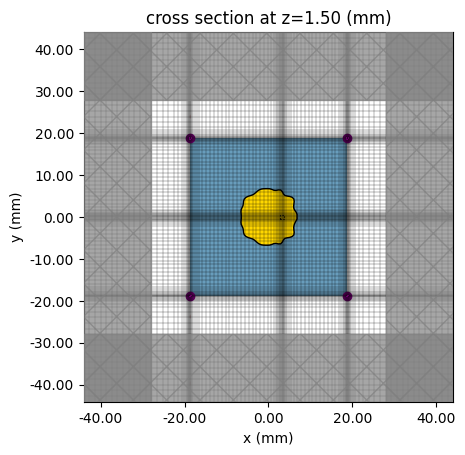

12:54:12 EST Billed flex credit cost: 0.025.

The antenna cost 0.025 FlexCredits to run. Each iteration of the optimization will cost around 0.050 FlexCredits to
complete.

In [48]:
# Turn the logging level to only show errors to not crowd the optimization output
td.config.logging_level = "ERROR"

# generate initial control radii with random perturbations for an irregular starting shape
np.random.seed(125124)
init_radius_control = np.random.normal(radius_init, radius_init_perturbation, num_control_vertices_per_side)

# plot the initial antenna structure and mesh
plot_structures_and_mesh(params_to_polyslabs(init_radius_control))

# compute initial poynting flux to be used in the objective function
initial_poynting_flux, initial_s11 = compute_poynting_and_s11(
    init_radius_control, log_simulation_cost=True
)

We run the optimization using the `Adam` optimizer from `optax` to modify the control radii according to the adjoint gradient. The radii are clipped at each step to stay within physically reasonable bounds.

In [49]:
# whether or not to restart the optimization from the current saved checkpoint
restart_optimization = False
restart_fname = "misc/rf_autograd_3_polyslab_patch_opt_state.pkl"

# Set up the objective function. Using autograd, we can find the gradient
# with respect to the first argument, which contains the control radii.
obj_val_and_grad = value_and_grad(objective_fn, argnum=[0])

# initialize patch parameters
patch_params = anp.array(init_radius_control.copy())

# set up optimization parameters and optimizer
learning_rate = 50
optimizer = optax.adam(learning_rate=learning_rate)
opt_state = optimizer.init(patch_params)

num_steps = 120

full_eval_period = 20
s11_sq_dB_evolution = []
s11_f_ghz = None
realized_gain_evolution = []

# set bounds on control radii
clip_min_radius = 0.035 * wavelength0
clip_max_radius = wavelength0

figure_of_merit = np.zeros(num_steps + 1)


def pack_optimization_state(iter_idx):
    optimization_state["iteration"] = iter_idx
    optimization_state["figure of merit"] = figure_of_merit
    optimization_state["realized gain evolution"] = realized_gain_evolution
    optimization_state["opt state"] = opt_state
    optimization_state["patch parameters"] = patch_params


optimization_state = {}
if not os.path.exists(restart_fname):
    pack_optimization_state(iter_idx=0)

if restart_optimization:
    with open(restart_fname, "rb") as file:
        optimization_state = pickle.load(file)

start_idx = 0
if restart_optimization:
    start_idx = optimization_state["iteration"]
    figure_of_merit[0:len(optimization_state["figure of merit"])] = optimization_state["figure of merit"]
    realized_gain_evolution = optimization_state["realized gain evolution"]
    opt_state = optimization_state["opt state"]
    patch_params = optimization_state["patch parameters"]

# run optimization loop, updating the control radii with the Adam optimizer
# at each step and clipping on the bounds
for step_idx in range(start_idx, num_steps):
    pack_optimization_state(iter_idx=step_idx)
    with open(restart_fname, "wb") as file:
        pickle.dump(optimization_state, file)

    f, g = obj_val_and_grad(patch_params, initial_poynting_flux)

    figure_of_merit[step_idx] = float(f)

    if (step_idx % full_eval_period) == 0:
        smatrix_data_eval, realized_gain_eval = evaluate_antenna(patch_params, freqs_s_params)
        smatrix_eval = smatrix_data_eval.smatrix()
        smatrix_f_ghz = smatrix_eval.data.coords["f"] / 1e9
        s11_f_ghz = smatrix_f_ghz.copy()
        s11_data_selection = smatrix_eval.data.isel(port_out=0, port_in=0)
        s11_sq_dB_evolution.append(20 * np.log10(np.abs(s11_data_selection.values.flatten())))

        realized_gain_evolution.append(
            {
                "Gtheta": realized_gain_eval["Gtheta"]
                .sel(phi=0, method="nearest")
                .squeeze()
                .values,
                "Gphi": realized_gain_eval["Gphi"].sel(phi=0, method="nearest").squeeze().values,
            }
        )

    updates, opt_state = optimizer.update(-g[0], opt_state, patch_params)

    patch_params = optax.apply_updates(patch_params, updates)
    patch_params = anp.array(patch_params)
    patch_params = anp.clip(patch_params, a_min=clip_min_radius, a_max=clip_max_radius)

    if (step_idx % print_iteration_frequency) == 0:
        output_text = Text.assemble(
            (f"Iteration {step_idx + 1}", "bold cyan"),
            "\n",
            ("\tFigure of merit: ", "bold"),
            (f"{f:.{print_decimal_places + 5}f}", "bold green"),
        )
        console.print(output_text)

figure_of_merit[num_steps] = objective_fn(patch_params, initial_poynting_flux)

Iteration 1
        Figure of merit: 0.1527225

Iteration 6
        Figure of merit: 0.3967066

Iteration 11
        Figure of merit: 1.0150869

Iteration 16
        Figure of merit: 1.2908257

Iteration 21
        Figure of merit: 1.4924213

...

Iteration 96
        Figure of merit: 7.3442978

Iteration 101
        Figure of merit: 7.3026233

Iteration 106
        Figure of merit: 7.7525698

Iteration 111
        Figure of merit: 7.2271619

Iteration 116
        Figure of merit: 7.2082067

Below, we plot the optimization output, including the figure of merit as a function of iteration and a comparison of the initial and final patch shapes. We also plot the evolution of the `S11` and realized gain throughout the optimization.

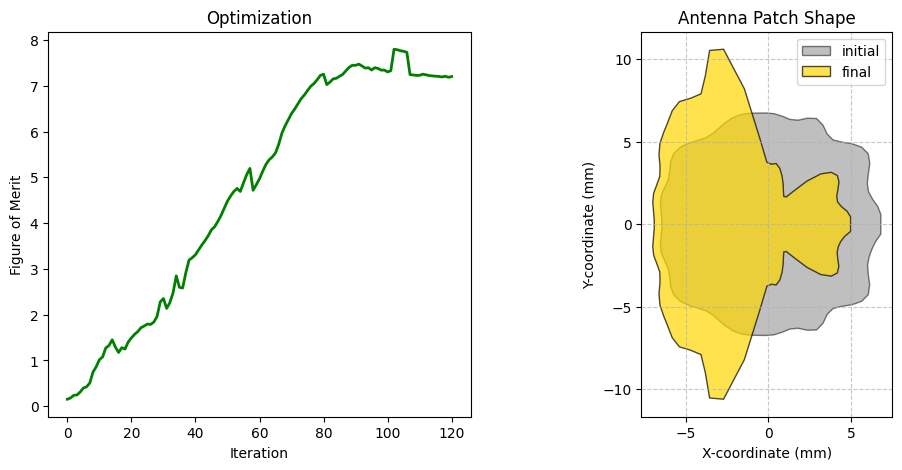

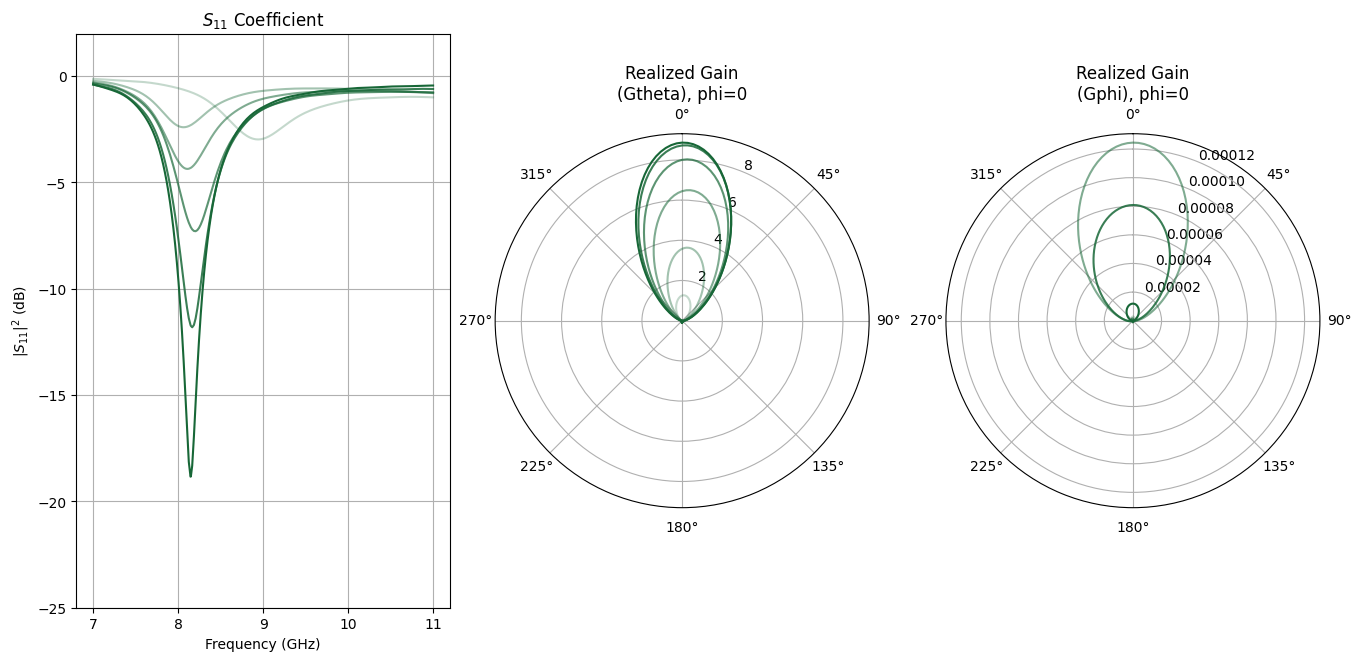

In [50]:
# Plot the results of the optimization including the trajectory and polygon shapes
initial_polyslab = params_to_polyslabs(init_radius_control)[0]
final_polyslab = params_to_polyslabs(patch_params)[0]

plot_optimization_results(figure_of_merit, initial_polyslab, final_polyslab)

# Plot the evolution of the antenna S11 and realized gain during the optimization
plot_antenna_evolution(
    s11_sq_dB_evolution,
    s11_f_ghz,
    realized_gain_evolution,
    opt_freqs,
)

We can also compare the `S11` and realized gain for the final optimization state with that of the initial state. On the `S11` plot, we indicate the target frequency that was optimized for.

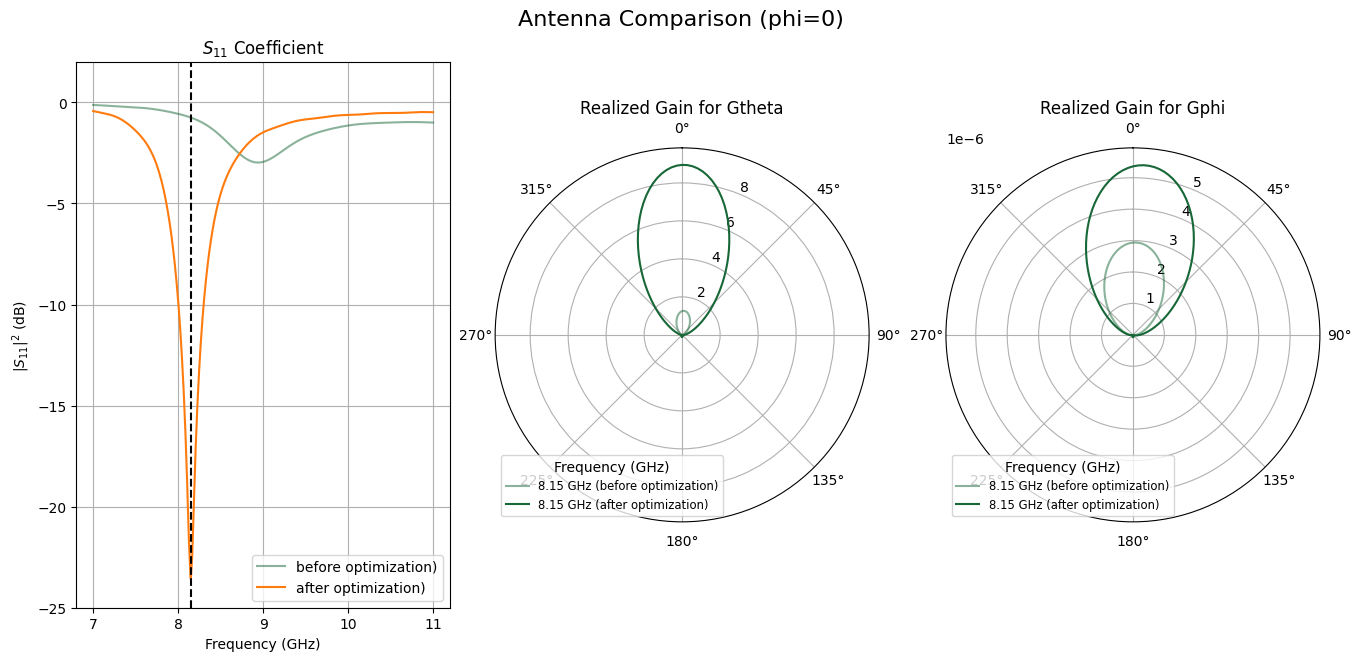

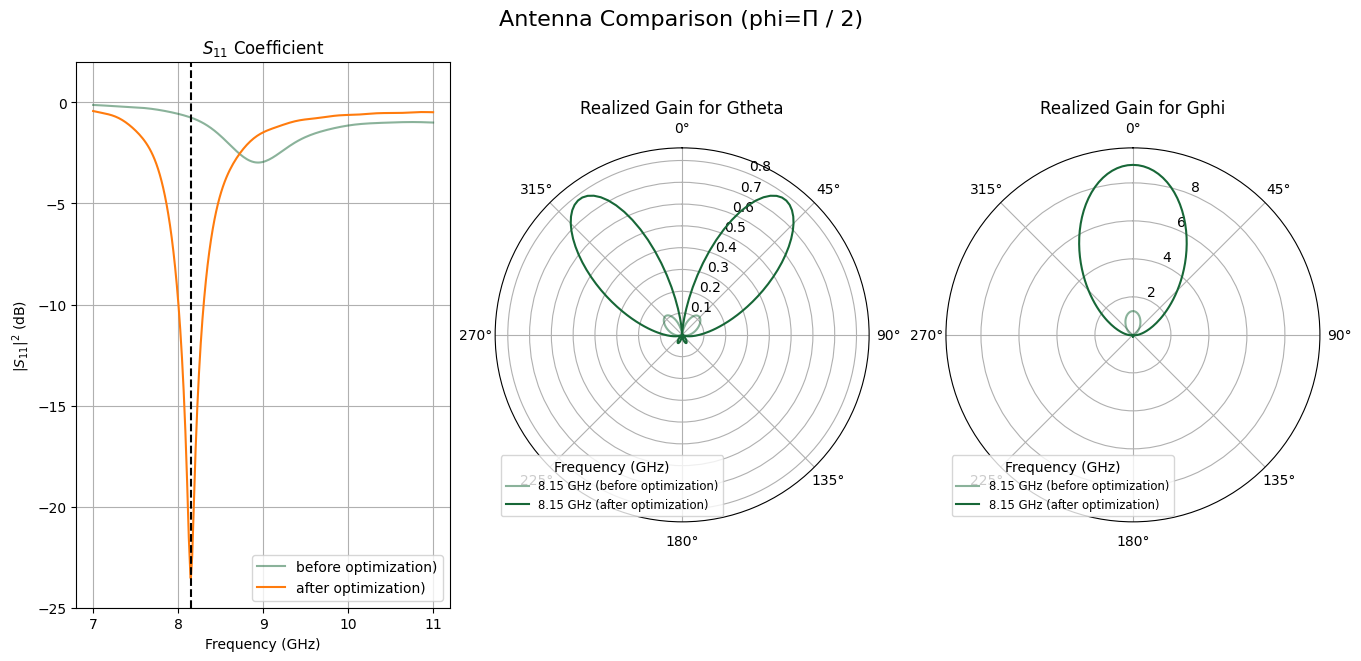

In [51]:
# Compute S11 and realized gain for the initial patch geometry
smatrix_data_init, realized_gain_init = evaluate_antenna(init_radius_control, freqs_s_params)
# Compute S11 and realized gain for the optimized patch geometry
smatrix_data_final, realized_gain_final = evaluate_antenna(patch_params, freqs_s_params)

# Plot the comparison in S11 and gain for the initial and optimized antennas for phi=0
plot_phi = 0.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=0)",
)

# Plot the comparison for phi=pi/2
plot_phi = np.pi / 2.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=\u03a0 / 2)",
)

# Save results of optimization
np.save("misc/rf_autograd_3_polyslab_patch_params.npy", patch_params)

By parameterizing the patch as a smooth polygon, we have demonstrated how gradient-based optimization can explore a much richer space of antenna shapes than axis-aligned rectangles allow. The spline-based parameterization with symmetric mirroring keeps the number of optimization variables manageable while producing smooth, manufacturable shapes. In future notebooks, we will extend this approach to include realistic material models such as lossy metals for a more complete comparison of optimized antenna performance.